In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
import shap
import joblib

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


In [15]:
df = pd.read_csv("AI_Credit_Scoring_Enhanced_Hackathon.csv")

df = df[(df["Age"] >= 18) & (df["Age"] <= 75)]
df = df.fillna(0)

print("Shape:", df.shape)


Shape: (90694, 33)


In [16]:
df["DTI_Ratio"] = df["EMI_Amount"] / (df["Monthly_Income"] + 1)
df["Savings_Ratio"] = df["Savings_Balance"] / (df["Monthly_Income"] + 1)
df["Cash_Flow_Ratio"] = df["Net_Profit"] / (df["Monthly_Income"] + 1)

df["Transaction_Intensity"] = df["Bank_Transaction_Count"] / 30
df["Digital_Activity_Score"] = df["UPI_Transaction_Count"] + df["Website_Traffic_Count"]

df["Expense_Sales_Ratio"] = df["Monthly_Expenses"] / (df["Monthly_Sales"] + 1)
df["Delay_Risk"] = df["Utility_Bill_Payment_Delay_Days"] / 90

np.random.seed(42)
df["Past_Default_Count"] = np.random.poisson(0.3, len(df))
df["Late_Payment_Frequency"] = np.random.poisson(1.2, len(df))

df["Income_Growth"] = np.random.normal(0.05, 0.03, len(df))
df["Sales_Growth"] = np.random.normal(0.07, 0.04, len(df))


In [17]:
economic_shock = np.random.normal(0, 0.15, len(df))

risk_score = (
    0.32 * df["DTI_Ratio"] +
    0.22 * df["Delay_Risk"] +
    0.15 * df["Expense_Sales_Ratio"] -
    0.12 * df["Savings_Ratio"] -
    0.10 * df["Cash_Flow_Ratio"] +
    0.08 * df["Late_Payment_Frequency"] +
    economic_shock
)

def sigmoid(x):
    return 1 / (1 + np.exp(-2*(x-0.5)))

prob_default = sigmoid(risk_score)
prob_default = 0.85 * prob_default + 0.15 * np.random.uniform(0,1,len(df))

df["Default_Flag"] = np.random.binomial(1, prob_default)

print(df["Default_Flag"].value_counts(normalize=True))


Default_Flag
0    0.691953
1    0.308047
Name: proportion, dtype: float64


c:\Users\Sarthak\anaconda3\envs\ml_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [18]:
features = [
    "DTI_Ratio",
    "Savings_Ratio",
    "Cash_Flow_Ratio",
    "Transaction_Intensity",
    "Digital_Activity_Score",
    "Expense_Sales_Ratio",
    "Delay_Risk",
    "Past_Default_Count",
    "Late_Payment_Frequency",
    "Income_Growth",
    "Sales_Growth"
]

X = df[features]
y = df["Default_Flag"]


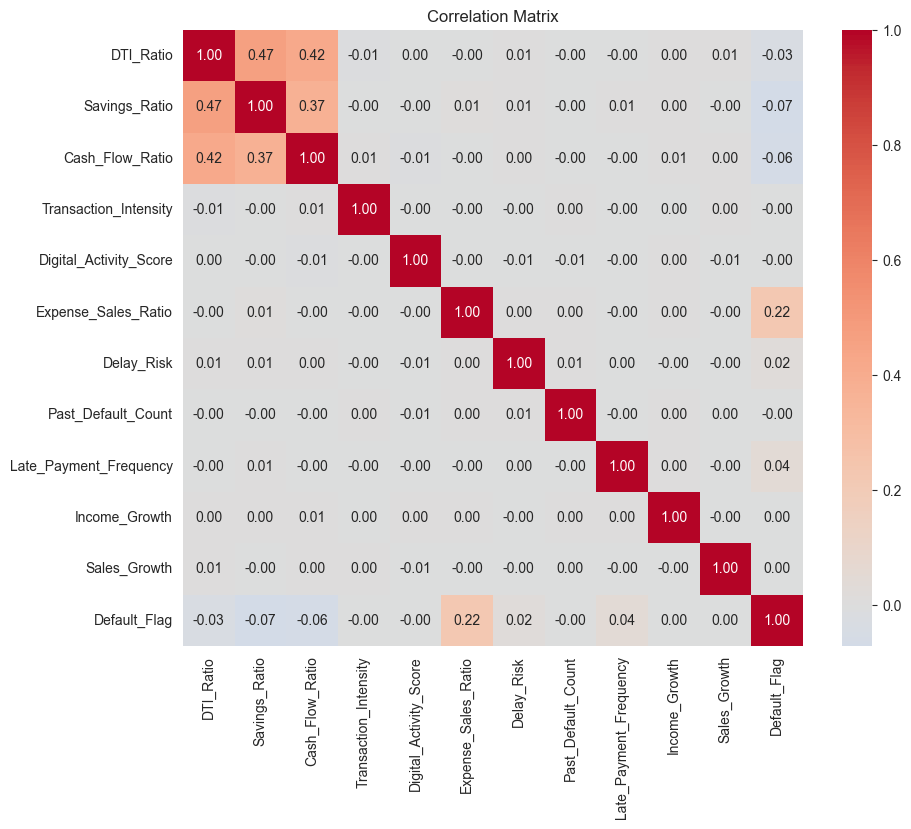

In [19]:
plt.figure(figsize=(10,8))
corr = df[features + ["Default_Flag"]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [21]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print("Logistic AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print("KNN AUC:", roc_auc_score(y_test, knn.predict_proba(X_test)[:,1]))


c:\Users\Sarthak\anaconda3\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic AUC: 0.6135371549503936
Random Forest AUC: 0.7148885375156834
KNN AUC: 0.6789697746864946


In [22]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

model_smote = XGBClassifier(eval_metric="logloss", random_state=42)
model_smote.fit(X_train_sm, y_train_sm)

y_prob_smote = model_smote.predict_proba(X_test)[:,1]
print("SMOTE XGBoost AUC:", roc_auc_score(y_test, y_prob_smote))


SMOTE XGBoost AUC: 0.7271512971528562


In [23]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_base = XGBClassifier(
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)


Class Imbalance Strategy

Both SMOTE oversampling and class-weighted XGBoost were evaluated to address class imbalance.

SMOTE XGBoost AUC: 0.727

Class-weighted XGBoost AUC: 0.753

The class-weighted approach provided better generalization performance on the test set and was selected as the final model.

In [24]:
param_dist = {
    "max_depth": [3,4,5,6,7],
    "learning_rate": [0.01,0.03,0.05,0.1],
    "n_estimators": [200,300,400],
    "subsample": [0.7,0.8,0.9],
    "colsample_bytree": [0.7,0.8,0.9],
    "gamma": [0,0.1,0.2]
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("CV AUC:", random_search.best_score_)


Best Parameters: {'subsample': 0.7, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.7}
CV AUC: 0.7473812188817793


ROC AUC: 0.7530126618115341
Accuracy: 0.6892882738849991
Precision: 0.49667682082525616
Recall: 0.6419112383679313
F1 Score: 0.5600312256049961
              precision    recall  f1-score   support

           0       0.82      0.71      0.76     12551
           1       0.50      0.64      0.56      5588

    accuracy                           0.69     18139
   macro avg       0.66      0.68      0.66     18139
weighted avg       0.72      0.69      0.70     18139



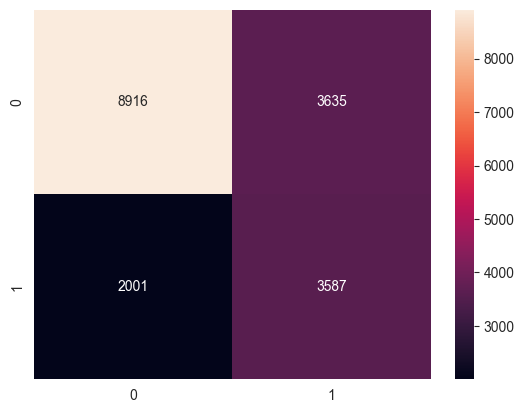

In [25]:
best_model.fit(X_train, y_train)

y_prob = best_model.predict_proba(X_test)[:,1]
y_pred = best_model.predict(X_test)

print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.show()


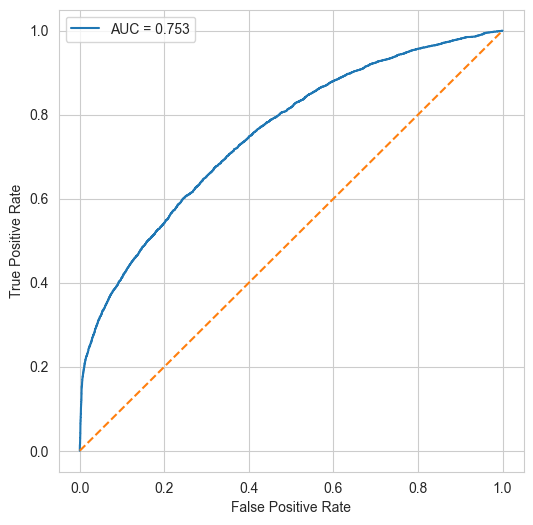

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [27]:
def ks_statistic(y_true, y_prob):
    df_ks = pd.DataFrame({"y": y_true, "prob": y_prob})
    df_ks = df_ks.sort_values("prob")
    df_ks["cum_good"] = (1 - df_ks["y"]).cumsum() / (1 - df_ks["y"]).sum()
    df_ks["cum_bad"] = df_ks["y"].cumsum() / df_ks["y"].sum()
    return max(abs(df_ks["cum_good"] - df_ks["cum_bad"]))

print("KS:", ks_statistic(y_test, y_prob))


KS: 0.3561508415742511


In [28]:
results = X_test.copy()
results["Actual_Default"] = y_test.values
results["Probability"] = y_prob

results["Risk_Segment"] = pd.qcut(
    results["Probability"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print(results.groupby("Risk_Segment")["Actual_Default"].mean())


Risk_Segment
Low Risk       0.122375
Medium Risk    0.270261
High Risk      0.531591
Name: Actual_Default, dtype: float64


In [29]:
results["Sex"] = df.loc[X_test.index, "Sex"]
results["Approved"] = results["Risk_Segment"] != "High Risk"

approval_rates = results.groupby("Sex")["Approved"].mean()
dir_ratio = approval_rates.min() / approval_rates.max()

print("Disparate Impact Ratio:", dir_ratio)


Disparate Impact Ratio: 0.9674084910039206


C:\Users\Sarthak\AppData\Local\Temp\ipykernel_18592\2350039927.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


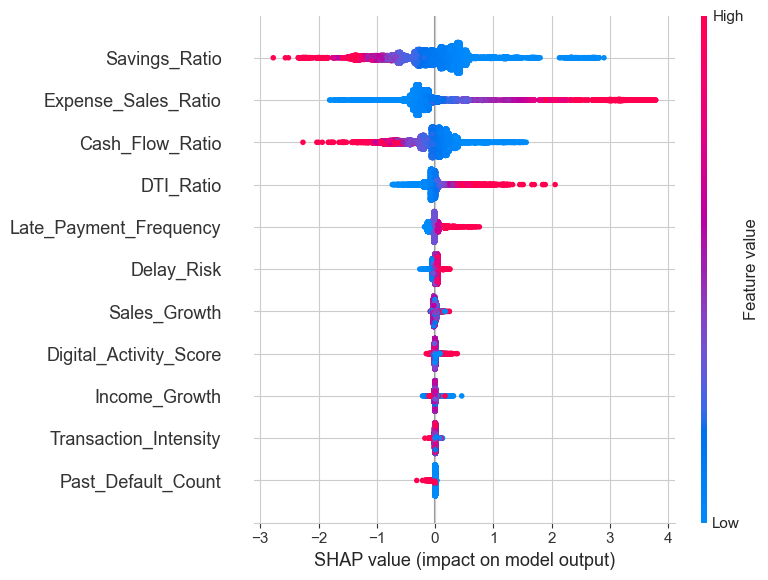

In [30]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)
